## Setup

In [1]:
import pandas as pd
import numpy as np
import os
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.model_selection import train_test_split
import tensorflow as tf
from src.functions import scatter_plot_fn

I0000 00:00:1787164574.358061   28175 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787164574.359823   28175 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787164574.524723   28175 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787164585.162239   28175 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

## Load data

In [2]:
crbn_binding_data = pd.read_excel('data/mmc3.xlsx', skiprows=1)
crbn_binding_data.head()

,Cxsmiles,Smiles,Catalog ID,"V, µL","Conc, mM",Formula,MW,Purity,Salt smiles,Salt_name,...,"Stereochem,data","Geometric,isomer",Chemical name,ClogP,logS,HBD,HBA,TPSA,RotBonds,FP Response
0,CC1(C)CC(=O)NC=2C=CC(=CC21)S(=O)(=O)NC=3C=CC=4...,CC1(C)CC(=O)NC=2C=CC(=CC21)S(=O)(=O)NC=3C=CC=4...,Z5000147527,10,10,C24H24N4O6S,496.5356,100.00,NaN,NaN,...,Racemic or presumed racemic or meso,NaN,"N-[2-(2,6-dioxopiperidin-3-yl)-1-oxo-2,3-dihyd...",1.614,-4.421,3,6,141.75,3,63.85
1,CCN1N=CC=C1S(=O)(=O)NC=2C=CC=3C(=O)N(CC3C2)C4C...,CCN1N=CC=C1S(=O)(=O)NC=2C=CC=3C(=O)N(CC3C2)C4C...,Z5000147208,10,10,C18H19N5O5S,417.4390,100.00,NaN,NaN,...,Racemic or presumed racemic or meso,NaN,"N-[2-(2,6-dioxopiperidin-3-yl)-1-oxo-2,3-dihyd...",0.024,-3.102,2,6,130.47,4,65.80
2,CC=1C=CC(=C2C=CC=CC12)S(=O)(=O)NC=3C=CC=4C(=O)...,CC=1C=CC(=C2C=CC=CC12)S(=O)(=O)NC=3C=CC=4C(=O)...,Z5000146412,10,10,C24H21N3O5S,463.5056,96.81,NaN,NaN,...,Racemic or presumed racemic or meso,NaN,"N-[2-(2,6-dioxopiperidin-3-yl)-1-oxo-2,3-dihyd...",2.773,-6.251,2,5,112.65,3,60.35
3,O=C1N(CC=2C=C(NS(=O)(=O)C3=C(C#N)SC=4C=CC=CC34...,O=C1N(CC=2C=C(NS(=O)(=O)C3=C(C#N)SC=4C=CC=CC34...,Z5000147289,10,10,C22H16N4O5S2,480.5162,98.53,NaN,NaN,...,Racemic or presumed racemic or meso,NaN,"2-cyano-N-[2-(2,6-dioxopiperidin-3-yl)-1-oxo-2...",2.107,-5.659,2,6,136.44,3,64.70
4,CCCC=1C=CC(=CC1)S(=O)(=O)NC=2C=CC=3C(=O)N(CC3C...,CCCC=1C=CC(=CC1)S(=O)(=O)NC=2C=CC=3C(=O)N(CC3C...,Z5000145522,10,10,C22H23N3O5S,441.5001,100.00,NaN,NaN,...,Racemic or presumed racemic or meso,NaN,"N-[2-(2,6-dioxopiperidin-3-yl)-1-oxo-2,3-dihyd...",2.657,-5.483,2,5,112.65,5,61.15


## Transform smiles to fingerprints (Morgan, radius 2, n_bits 2048)

In [3]:
morgan_gen = AllChem.GetMorganGenerator(radius=2, fpSize=2048)

def smiles_to_fp_list(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return [np.nan] * 2048
    fp = morgan_gen.GetFingerprint(mol)
    return(list(fp))

ai_data = pd.DataFrame(crbn_binding_data["Smiles"].apply(smiles_to_fp_list).tolist())
ai_data = pd.concat([ai_data, crbn_binding_data[["Catalog ID", "FP Response"]].rename(columns={"Catalog ID": "id", "FP Response": "binding"}) ], axis=1)
ai_data.head()

,0,1,2,3,4,5,6,7,8,9,...,2040,2041,2042,2043,2044,2045,2046,2047,id,binding
0,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Z5000147527,63.85
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Z5000147208,65.80
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Z5000146412,60.35
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Z5000147289,64.70
4,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Z5000145522,61.15


## Split data (80% train test split)

In [4]:
X = ai_data.iloc[:, :-2]
y = ai_data["binding"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Deep learning

#### training

In [5]:
model = tf.keras.Sequential([
    tf.keras.Input(shape = (2048, )),
    tf.keras.layers.Dense(units = 64, activation = 'relu'),
    tf.keras.layers.Dense(units = 64, activation = 'relu'),
    tf.keras.layers.Dense(units = 64, activation = 'relu'),
    tf.keras.layers.Dense(units=1)
])

E0000 00:00:1787164628.580200   28175 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1787164628.580838   28521 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1787164628.630818   28175 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [6]:
model.compile(loss = "mean_squared_error", optimizer=tf.keras.optimizers.Adam(
         learning_rate=0.0001,
        clipnorm=1.0
))

In [7]:
model.fit(X_train, y_train, epochs=100)

Epoch 1/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 18194.0059
Epoch 2/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 16350.9277
Epoch 3/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 12051.1943
Epoch 4/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5796.9541
Epoch 5/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1921.9713
Epoch 6/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1383.6575
Epoch 7/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1068.7657
Epoch 8/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 813.3077
Epoch 9/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 644.2399
Epoch 10/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 528.1479
Epoch 11/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 456.7881
Epoch 12/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 407.3951
Epoch 13/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 369.1187
Epoch 14/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 339.3123
Epoch

#### Prediction

In [8]:
y_pred = model.predict(X_test).flatten()

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


#### Visualization

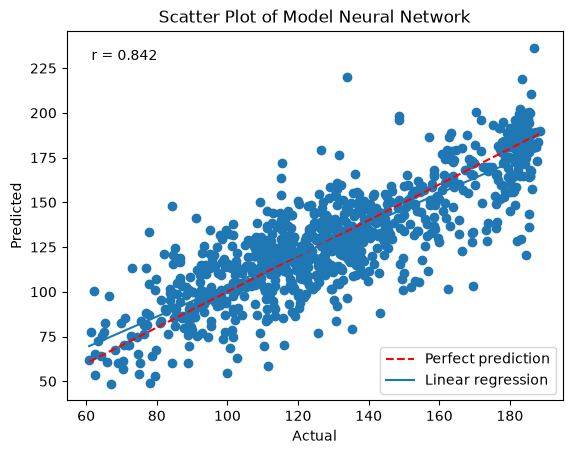

In [9]:
scatter_plot_fn(y_test, y_pred, "Neural Network")